In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
read_one_case = True
full_years = True
plot_2d_comparison = False
plot_corrected = False

In [3]:
# step = '183000'
# # Xaver case:
# if not plot_corrected:
#     ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/xaver_2013-12-01_240h_step{step}.nc'
#     odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case'
# else:
#     ifile = f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step{step}.nc'
#     odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/xaver_case'
# prefix = f'step{step}_'

# ifile = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/lam-8760h_test.nc'
# odir  = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/oneyear'
# prefix = 'lam-8760h_'

# if not plot_corrected:
#     odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/'
# else:
#     odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/figures/'

idir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference'
ifile = os.path.join(idir, '2013-12-01_xaver2013_step060000.nc')
odir = os.path.join(idir, 'figures', 'xaver_case')

# Compare with 2013 NORA-surge:
comparewith = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2/2013/ocean_his.nc'
if plot_corrected:
    comparewith2 = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/2013/ocean_his.nc'

In [4]:
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)

In [5]:
if read_one_case:
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    lat = nc.latitude
    lon = nc.longitude
    time = nc.time
    # x_wind_10m = nc.x_wind_10m
    #
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    lat2 = np.reshape(lat.values, (570, 1014))
    lon2 = np.reshape(lon.values, (570, 1014))
    # x_wind_10m2 = np.reshape(x_wind_10m.values, (x_wind_10m.shape[0], 570, 1014))

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [6]:
nc_c = xr.open_dataset(comparewith)
zeta_c = nc_c.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid
lat_c = nc_c.lat_rho[5:575,5:1019]
lon_c = nc_c.lon_rho[5:575,5:1019]
time_c = nc_c.ocean_time
mask_c = nc_c.mask_rho[5:575,5:1019]
timee_c = np.array([np.datetime64(t) for t in time_c.values])
if plot_corrected:
    nc_c2 = xr.open_dataset(comparewith2)
    zeta_c2 = nc_c2.zeta[:,5:575,5:1019]  # cut away the outermost grid cells to match the lam grid

In [7]:
if read_one_case:
    # Find index of time in time_c
    timee = np.array([np.datetime64(t) for t in time.values])
    timee_c = np.array([np.datetime64(t) for t in time_c.values])
    time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]

In [3]:
if read_one_case and plot_2d_comparison:
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning) # Suppress UserWarnings
    # Plot the same as above, but with two subplots, one for the inference and one for the comparison
    minval = -2
    maxval = 2
    colormap = 'RdBu_r'
    # for i in range(0, 180, 3):
    for i in range(0, len(time), 12):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        pcm1 = ax1.pcolormesh(lon2, lat2, zeta2[i,:,:], cmap=colormap, vmin=minval, vmax=maxval)
        ax1.set_title(f'Inference\nTime index: {i}')
        fig.colorbar(pcm1, ax=ax1, label='zeta[m]')
        if plot_corrected:
            pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c2[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
            print(f'Using corrected comparison data for time index {i}')
        else:
            pcm2 = ax2.pcolormesh(lon_c, lat_c, zeta_c[time_indices[i], :, :]*mask_c, cmap=colormap, vmin=minval, vmax=maxval)
        ax2.set_title(f'Comparison\nTime index: {time_indices[i]}, Time value: {timee_c[time_indices[i]]}')
        fig.colorbar(pcm2, ax=ax2, label='zeta[m]')
        pcm3 = ax3.pcolormesh(lon_c, lat_c, zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c, cmap='bwr', vmin=-1, vmax=1)
        ax3.set_title(f'Difference\nTime index: {i}')
        fig.colorbar(pcm3, ax=ax3, label='zeta[m]')
        plt.tight_layout()
        plt.savefig(os.path.join(odir, f'{prefix}zeta_compare_{i:04d}.png'), dpi=100)
        # plt.show()
        plt.close()
        print(f'Plotted index {i}, number of plots left: {len(time)-i-1}, filename: {os.path.join(odir, f"{prefix}zeta_compare_{i:04d}.png")}')

In [4]:
# Rename all the files to have leading zeros in the index for proper sorting
if False:
    for filename in os.listdir(odir):
        if filename.startswith(f'{prefix}zeta_compare_') and filename.endswith('.png'):
            parts = filename.split('_')
            index_part = parts[-1].split('.')[0]
            index_int = int(index_part)
            new_filename = f'{prefix}zeta_compare_{index_int:04d}.png'
            os.rename(os.path.join(odir, filename), os.path.join(odir, new_filename))
            print(f'Renamed {filename} to {new_filename}')

In [15]:
if read_one_case:
    # Using "convert" in os.system to create a gif from the png files
    os.system(f'convert -delay 10 -loop 0 {odir}/{prefix}zeta_compare*.png {odir}/{prefix}zeta.gif')
    print(f'{odir}/{prefix}zeta.gif created successfully.')

/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/oneyear/lam-8760h_zeta.gif created successfully.


In [130]:
# LIst all the gif files in odir
gif_files = [f for f in os.listdir(odir) if f.endswith('.gif')]
print('GIF files in output directory:')
for gif in gif_files:
    print(os.path.join(odir, gif))

GIF files in output directory:
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case/step072000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case/step100000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case/step057000_zeta_xaver.gif
/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/xaver_case/step046000_zeta_xaver.gif


TODO: Plot timseries for all runs, start with Cuxhaven

In [8]:
# Read obs:
idir_obs          = '/lustre/storeB/users/nilsmk/stormrisk'
ifile_tseries_obs = os.path.join(idir_obs, 'aggregated_water_level_observations_with_pytide_prediction_dataset_extended_nor_stations_with_4_nora-surge_exps.nc')
nc_timeseries_selected = xr.open_dataset(ifile_tseries_obs)

In [9]:
if read_one_case:
    # Cuxhaven coordinates
    sta_lat = 53.87
    sta_lon = 8.72
    staname = 'Cuxhaven'
    sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'DE_Cuxhaven')[0][0]
    # Oscarsborg coordinates 66 NO_OSC 59.678074 10.604861
    # sta_lat = 59.68
    # sta_lon = 10.60
    # staname = 'Oscarsborg'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_OSC')[0][0]
    # Bergen coordinates 53 NO_BGO 60.398045 5.320487
    # sta_lat = 60.40
    # sta_lon = 5.32
    # staname = 'Bergen'
    # sta_idx = np.where(nc_timeseries_selected.stationid[:].values == 'NO_BGO')[0][0]
    # Do the same for the comparison data
    lat_c_arr = np.array(lat_c[:])
    lon_c_arr = np.array(lon_c[:])
    dist_c = np.sqrt((lat_c_arr - sta_lat)**2 + (lon_c_arr - sta_lon)**2)
    min_index_c = np.unravel_index(np.argmin(dist_c), dist_c.shape)
    print(f'Nearest point to {staname} in comparison data: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
    # If land point, find new position:
    if mask_c[min_index_c] == 0:
        print('Nearest point is on land, searching for nearest sea point...')
        sea_indices = np.where(mask_c == 1)
        sea_lats = lat_c_arr[sea_indices]
        sea_lons = lon_c_arr[sea_indices]
        dist_sea = np.sqrt((sea_lats - sta_lat)**2 + (sea_lons - sta_lon)**2)
        min_sea_index = np.argmin(dist_sea)
        min_index_c = (sea_indices[0][min_sea_index], sea_indices[1][min_sea_index])
        print(f'New nearest sea point: lat={lat_c_arr[min_index_c]}, lon={lon_c_arr[min_index_c]} at index {min_index_c}')
        # Update sta_lat and sta_lon
        sta_lat = lat_c_arr[min_index_c]
        sta_lon = lon_c_arr[min_index_c]
    # Find the nearest point in the lat/lon grid
    import numpy as np
    lat_arr = np.array(lat[:])
    lon_arr = np.array(lon[:])
    dist = np.sqrt((lat_arr - sta_lat)**2 + (lon_arr - sta_lon)**2)
    min_index = np.unravel_index(np.argmin(dist), dist.shape)
    print(f'Nearest point to {staname}: lat={lat_arr[min_index]}, lon={lon_arr[min_index]} at index {min_index}')

Nearest point to Cuxhaven in comparison data: lat=53.877716064453125, lon=8.72961711883545 at index (1, 259)
Nearest point is on land, searching for nearest sea point...
New nearest sea point: lat=53.926902770996094, lon=8.723377227783203 at index (2, 260)
Nearest point to Cuxhaven: lat=53.926902770996094, lon=8.723377227783203 at index (2288,)


In [21]:
import glob
# if plot_corrected:
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/xaver_2013-12-01_240h_step*.nc')
# else:
# ifiles = glob.glob('/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/xaver_2013-12-01_240h_step*.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_*/inference/xaver_2013-12-01_240h_step{step}.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/????-??-??_240h_step{step}.nc')
# ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/????-??-??_240h_step{step}.nc')
ifiles = glob.glob(os.path.join(idir, f'????-??-??_xaver2013_step*.nc'))
ifiles.sort()
prefix = 'longrun30yrs_'

In [22]:
for ifile in ifiles:
    print(f'Processing file: {ifile}')

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc


In [14]:
# Read obs:
# selected_timeseries = (nc_timeseries_selected['observation']-nc_timeseries_selected['pytide_prediction']).sel(time=slice(time[0], time[-1]))[:,sta_idx]
selected_timeseries = nc_timeseries_selected.sel(time=slice(time[0], time[-1]))
obs_surge = (selected_timeseries['observation']-selected_timeseries['pytide_prediction'])[sta_idx,:]*0.01  # Convert cm to m

RMSE for step 060000: 0.1478 m
RMSE for step 090000: 0.2361 m
RMSE for step 120000: 0.1880 m
RMSE for step 150000: 0.0897 m
RMSE for step 180000: 0.1108 m


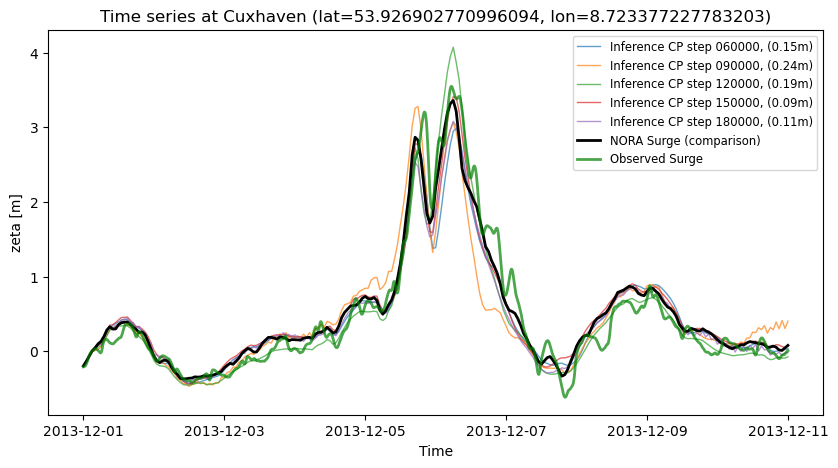

In [23]:
#
# Plot the time series for the station for all inference runs and the comparison data in one plot
fig, ax = plt.subplots(figsize=(10, 5))
for file in ifiles:
    nc = xr.open_dataset(file)
    zeta = nc.zeta
    time = nc.time
    # Calculate RMSE for this time series compared to the comparison data
    zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]].values
    zeta_series = zeta[:, min_index[0]].values
    rmse = np.sqrt(np.mean((zeta_series - zeta_c_series)**2))
    print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
    ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, ({rmse:.2f}m)', lw=1, alpha=0.7)
# Plot the comparison data time series
ax.plot(time_c[time_indices], zeta_c[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge (comparison)', lw=2, color='k')
if plot_corrected:
    ax.plot(time_c[time_indices], zeta_c2[time_indices, min_index_c[0], min_index_c[1]], label='NORA Surge Corrected (comparison)', lw=2, color='orange')
# Plot obs surge:
ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=2, color='green', alpha=0.7)
ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
ax.set_xlabel('Time')
ax.set_ylabel('zeta [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
plt.show()

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
RMSE for step 060000: 0.1478 m


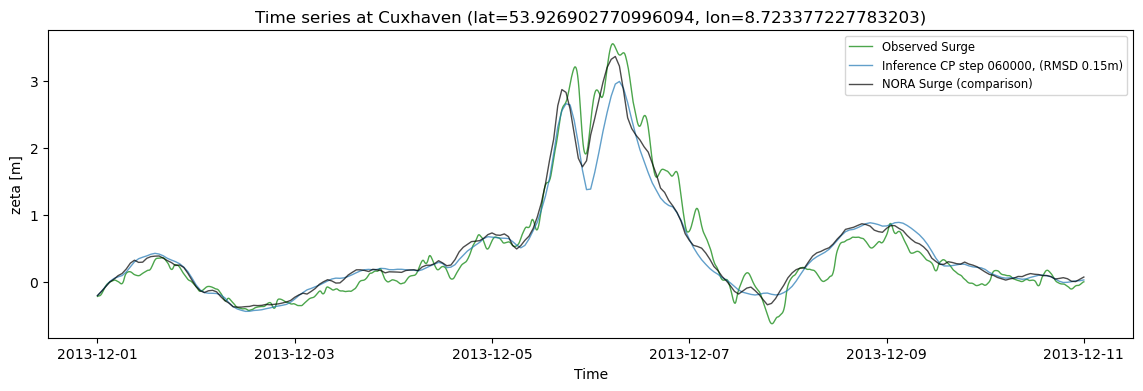

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
RMSE for step 090000: 0.2361 m


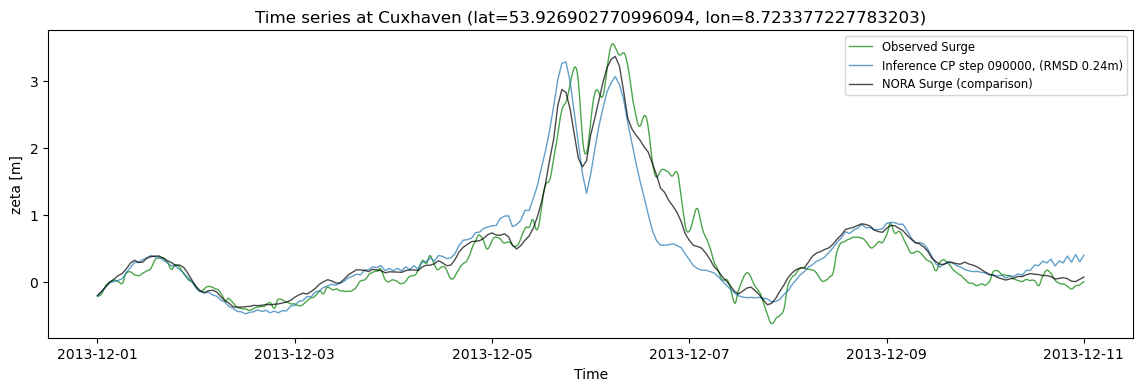

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
RMSE for step 120000: 0.1880 m


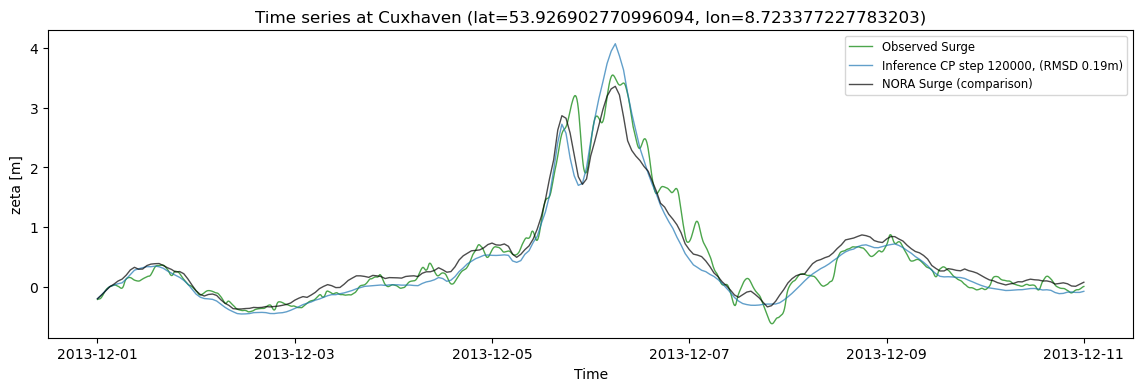

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
RMSE for step 150000: 0.0897 m


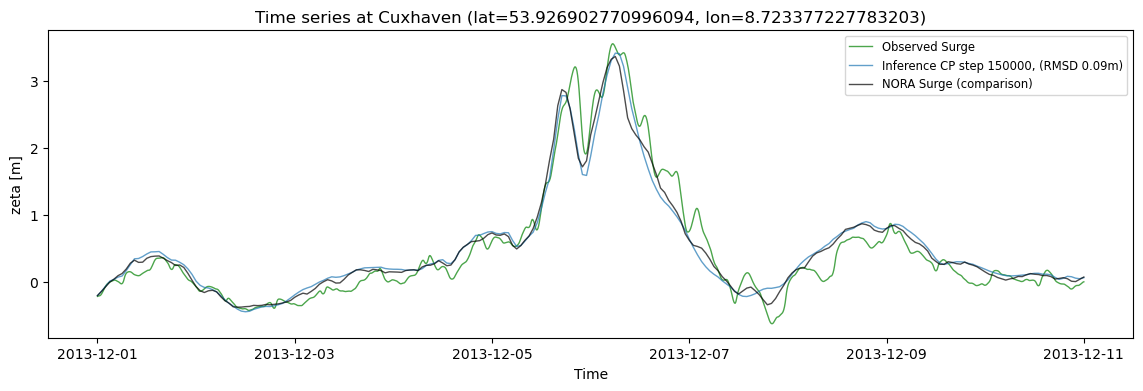

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc
RMSE for step 180000: 0.1108 m


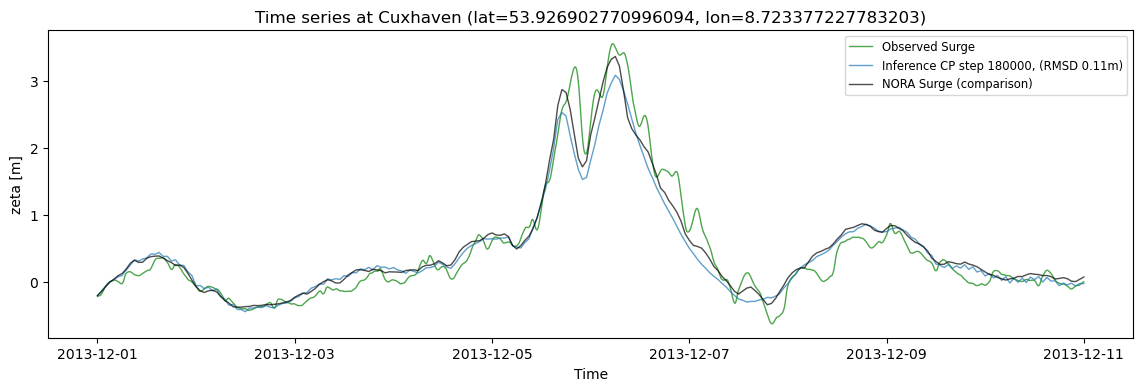

In [24]:
if True:
    linewdth = 1
    # Plot the individual time series
    for file in ifiles:
        print(f'Processing file: {file}')
        fig, ax = plt.subplots(figsize=(14, 4))
        # Plot obs surge:
        ax.plot(selected_timeseries.time, obs_surge, label='Observed Surge', lw=linewdth, color='green', alpha=0.7)
        nc = xr.open_dataset(file)
        zeta = nc.zeta
        time = nc.time
        zeta_series = zeta[:, min_index[0]].values
        # Calculate RMSE for this time series compared to the comparison data
        if plot_corrected:
            zeta_c_series2 = zeta_c2[time_indices, min_index_c[0], min_index_c[1]]
        zeta_c_series = zeta_c[time_indices, min_index_c[0], min_index_c[1]]
        try:
            if plot_corrected:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
            else:
                rmse = np.sqrt(np.mean((zeta_series - zeta_c_series.values)**2))
        except:
            rmse = np.nan
        ax.plot(time, zeta[:, min_index[0]], label=f'Inference CP step {file[-9:-3]}, (RMSD {rmse:.2f}m)', lw=linewdth, alpha=0.7)
        # Plot the comparison data time series
        ax.plot(time_c[time_indices], zeta_c_series, label='NORA Surge (comparison)', lw=linewdth, color='k', alpha=0.7)
        if plot_corrected:
            ax.plot(time_c[time_indices], zeta_c_series2, label='NORA Surge Corrected (comparison)', lw=linewdth, color='grey', alpha=0.7)
        print(f'RMSE for step {file[-9:-3]}: {rmse:.4f} m')
        ax.set_title(f'Time series at {staname} (lat={sta_lat}, lon={sta_lon})')
        ax.set_xlabel('Time')
        ax.set_ylabel('zeta [m]')
        ax.legend(fontsize='small')
        # plt.savefig(os.path.join(odir, f'{prefix}zeta_timeseries_{staname}.png'), dpi=100)
        plt.show()

In [25]:
# Calulate RMSE between inference and NORA surge for all time steps for all runs, and plot as time series
rmse = np.zeros((len(ifiles), len(time)))
for ifile_idx, ifile in enumerate(ifiles):
    print(f'Processing file: {ifile}')
    nc = xr.open_dataset(ifile)
    zeta = nc.zeta
    zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
    for i in range(len(time)):
        if plot_corrected:
            rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
        else:
            rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))


Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step060000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step090000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step120000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step150000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-12-01_xaver2013_step180000.nc


RMSD time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/figures/xaver_case/longrun30yrs_zeta_rmsd_timeseries.png


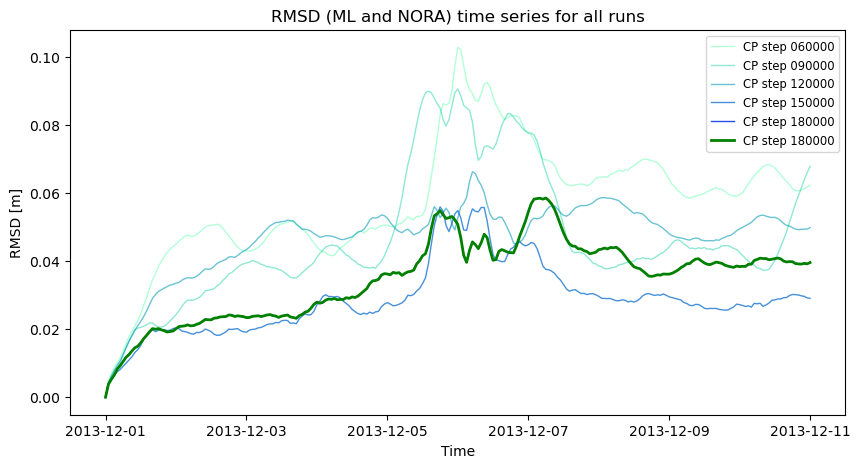

In [26]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(10, 5))
for ifile_idx, ifile in enumerate(ifiles):
    # alpha = (ifile_idx+1)/len(ifiles)
    alpha = 0.3 + 0.7*(ifile_idx/len(ifiles))
    color = cm.winter_r(ifile_idx/len(ifiles))
    ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=1, alpha=alpha, color=color)
    if ifile_idx == len(ifiles)-1:
        ax.plot(time, rmse[ifile_idx, :], label=f'CP step {ifile[-9:-3]}', lw=2, color='g')
ax.set_title(f'RMSD (ML and NORA) time series for all runs')
ax.set_xlabel('Time')
ax.set_ylabel('RMSD [m]')
ax.legend(fontsize='small')
plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
plt.show()

### Do one year of data

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
# Run top cells first
plot_corrected = False
do_one_year = True
read_only_one_yearly_file = False

In [3]:
odir = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/analysis/'
# Create odir if it does not exist
import os
if not os.path.exists(odir):
    os.makedirs(odir)
if not plot_corrected:
    prefix = f'allruns2013_uncorr_step{step}_'
else:
    prefix = f'allruns2013_corrected_step{step}_'


In [4]:
if not read_only_one_yearly_file:
    ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/????-??-??_10day_step{step}.nc')
    # if plot_corrected:
    #     ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_corrected/inference/????-??-??_10day_step{step}.nc')
    # else:
    #     ifiles = glob.glob(f'/lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/????-??-??_10day_step{step}.nc')
else:
    # If only dealing with one single yearly file:
    ifiles = [ifile]
ifiles.sort()


In [9]:
# Store the rmse array as a pandas DataFrame and save as csv file
if do_one_year:
    import pandas as pd
    csv_file = os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.csv')
    if not os.path.isfile(csv_file):
        # Calulate RMSD between inference and NORA surge for all time steps for all runs
        for ifile_idx, ifile in enumerate(ifiles):
            print(f'Processing file: {ifile}')
            nc = xr.open_dataset(ifile)
            zeta = nc.zeta
            zeta2 = np.reshape(zeta.values, (zeta.shape[0], 570, 1014))
            time = nc.time
            if ifile_idx == 0:
                rmse = np.zeros((len(ifiles), len(time)))
            # Find index of time in time_c
            timee = np.array([np.datetime64(t) for t in time.values])
            time_indices = np.where((timee_c >= timee[0]) & (timee_c <= timee[-1]))[0]
            for i in range(len(time)):
                try:
                    if not plot_corrected:
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c[time_indices[i], :, :]*mask_c)**2))
                    else:
                        rmse[ifile_idx, i] = np.sqrt(np.mean((zeta2[i,:,:]-zeta_c2[time_indices[i], :, :]*mask_c)**2))
                except Exception as e:
                    print(f"Error processing time index {i} in file {ifile}: {e}")
        # Create DataFrame and save to CSV
        if not read_only_one_yearly_file:
            rmse_df = pd.DataFrame(rmse, index=[ifile[-29:-19] for ifile in ifiles], columns=[str(t) for t in np.arange(time.shape[0])])
        else:
            rmse_df = pd.DataFrame(rmse, index=['singlefile'], columns=[str(t) for t in np.arange(time.shape[0])])
        rmse_df.to_csv(csv_file)
        print(f'RMSD time series saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.csv")}')
    else:
        print(f'CSV file {csv_file} already exists. Skipping saving.')
        rmse_df = pd.read_csv(csv_file, index_col=0)

Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-01-02_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-01-12_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-01-22_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-02-01_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-02-11_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-02-21_10day_step183000.nc
Processing file: /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_graph10.3_1980-2012/inference/2013-03-03_10day_step183000.nc
Processing file: /lustre/storeB/users/nil

RMSD time series plot saved to /lustre/storeB/users/nilsmk/anemoi-datasets/output/longrun_10years_newgraph_90s_uncorr/inference/figures/allruns2013_uncorr_step183000_zeta_rmsd_timeseries.png


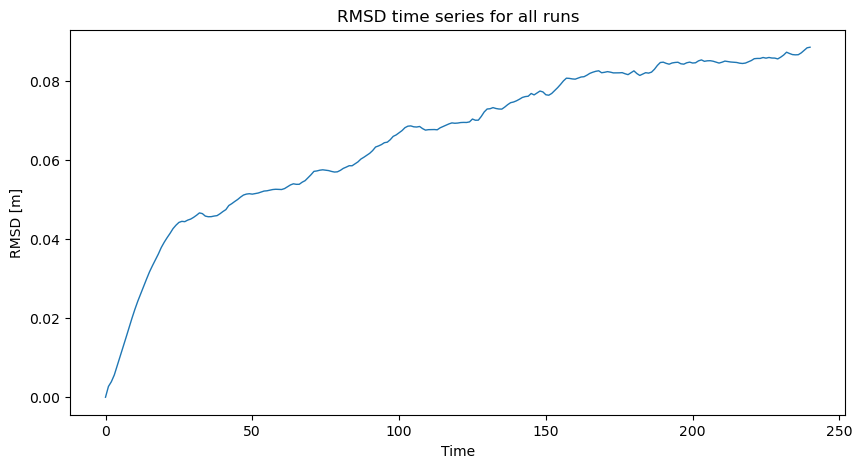

In [10]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(rmse_df.shape[1]), np.median(rmse_df, axis=0), label=f'RMSE', lw=1)
    # ax.set_xlim(0,480)
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    # ax.legend(fontsize='small')
    plt.savefig(os.path.join(odir, f'{prefix}zeta_rmsd_timeseries.png'), dpi=100)
    print(f'RMSD time series plot saved to {os.path.join(odir, f"{prefix}zeta_rmsd_timeseries.png")}')
    plt.show()

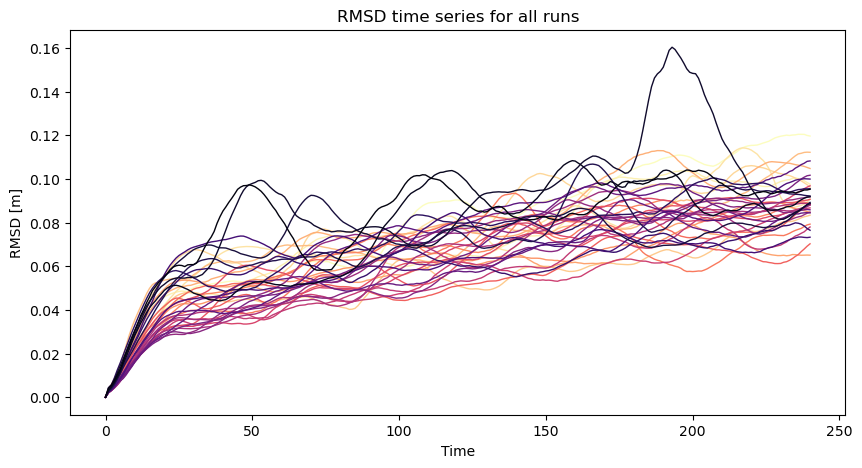

In [11]:
# Plot the RMSE time series for all runs, color them by the CP step using viridis colormap
if do_one_year:
    import matplotlib.cm as cm
    fig, ax = plt.subplots(figsize=(10, 5))
    for ifile_idx in np.arange(rmse_df.shape[0]):
        ax.plot(np.arange(rmse_df.shape[1]), rmse_df.values[ifile_idx, :], lw=1, color=cm.magma_r(ifile_idx/rmse_df.shape[0]))
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('RMSD [m]')
    plt.show()

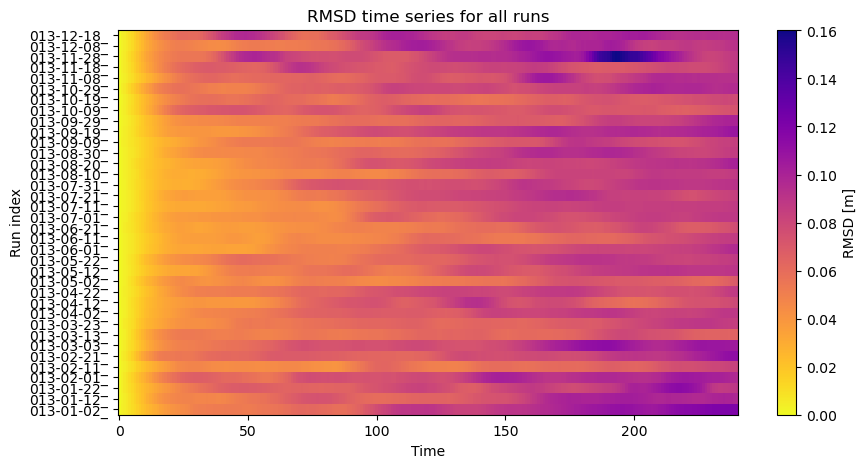

In [12]:
# Plot rmse_df as pcolormesh
if do_one_year:
    fig, ax = plt.subplots(figsize=(10, 5))
    pcm = ax.pcolormesh(rmse_df.columns.astype(int), rmse_df.index, rmse_df.values, cmap='plasma_r')
    ax.set_title(f'RMSD time series for all runs')
    ax.set_xlabel('Time')
    ax.set_ylabel('Run index')
    fig.colorbar(pcm, ax=ax, label='RMSD [m]')
    plt.show()